## 1. Data Preparation:

**Load the dataset into your preferred data analysis environment (e.g., Python with libraries like Pandas and NumPy).**


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:
df = pd.read_excel('dataset/heart_disease.xlsx',sheet_name=1)

In [8]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


## 2. Exploratory Data Analysis (EDA):

**Perform exploratory data analysis to understand the structure of the dataset.**

**Check for missing values, outliers, and inconsistencies in the data.**

**Visualize the distribution of features, including histograms, box plots, and correlation matrices.**


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB


In [10]:
df.shape

(908, 13)

In [11]:
df.describe()

,age,trestbps,chol,thalch,oldpeak,num
count,908.000000,908.000000,908.000000,908.000000,846.000000,908.000000
mean,53.791850,133.430617,201.484581,135.957048,0.891253,1.008811
std,9.158031,20.401608,112.097949,26.804929,1.093875,1.144436
min,29.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.750000,120.000000,176.750000,118.000000,0.000000,0.000000
50%,54.000000,130.000000,224.000000,138.000000,0.500000,1.000000
75%,60.000000,144.000000,270.000000,156.000000,1.500000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,4.000000


In [12]:
df.isnull().sum()

age          0
sex          0
cp           0
trestbps     0
chol         0
fbs          0
restecg      0
thalch       0
exang        0
oldpeak     62
slope        0
thal         0
num          0
dtype: int64

In [14]:
df['oldpeak'].fillna(df['oldpeak'].median(), inplace=True)

In [15]:
df.isnull().sum()

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalch      0
exang       0
oldpeak     0
slope       0
thal        0
num         0
dtype: int64

In [52]:
df['num'].unique()

array([0, 1, 2, 3, 4], dtype=int64)

In [17]:
num_cols = df.select_dtypes(include=['int64','float64']).columns
num_cols

Index(['age', 'trestbps', 'chol', 'thalch', 'oldpeak', 'num'], dtype='object')

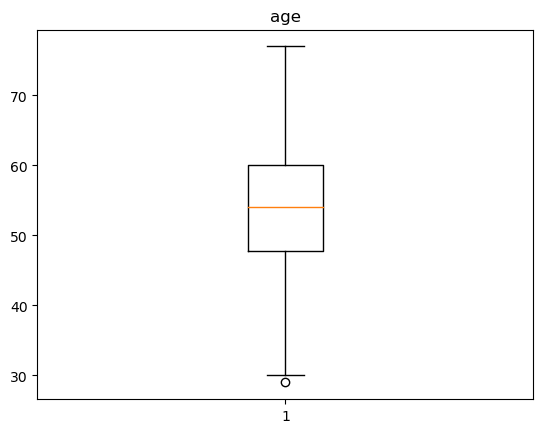

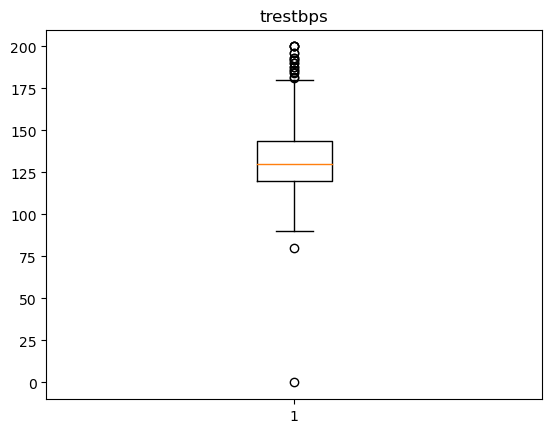

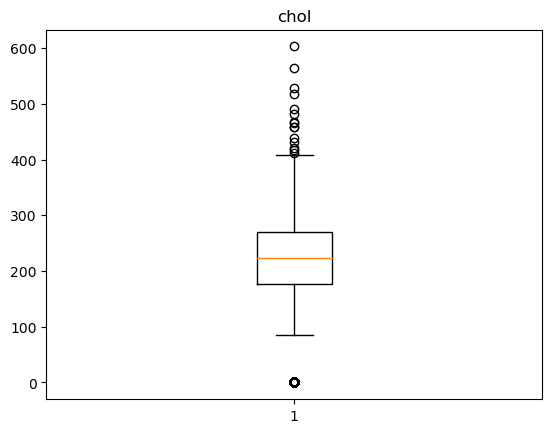

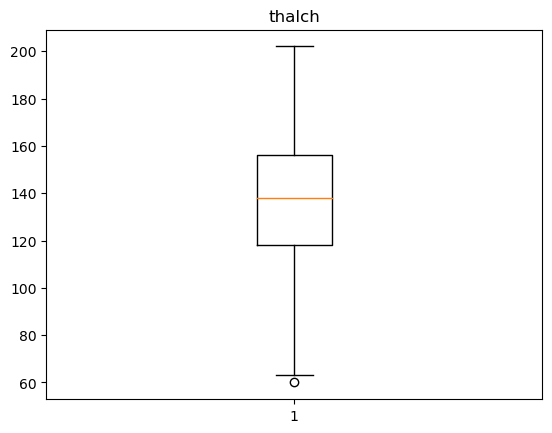

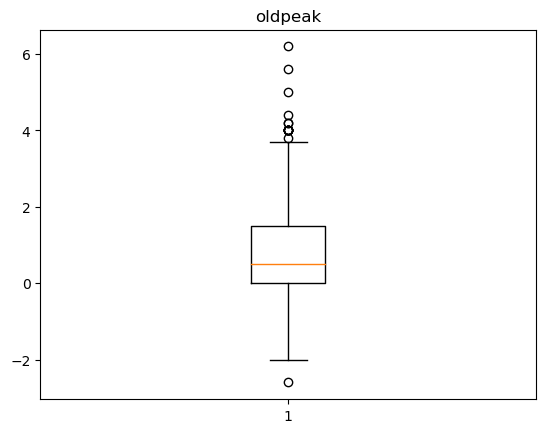

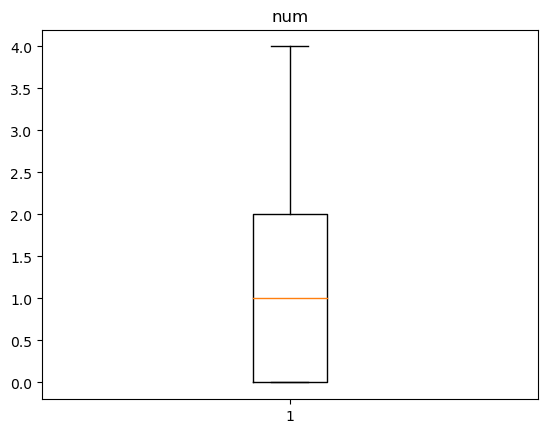

In [18]:
# Outliers Detection

for i in num_cols:
    plt.boxplot(df[i])
    plt.title(i)
    plt.show()

In [21]:
# Outlier Removal using IQR

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    UE = Q3 + 1.5*(IQR)
    LE = Q1 - 1.5*(IQR)
    
    df.loc[df[col]>UE, col] = UE
    df.loc[df[col]<LE, col] = LE

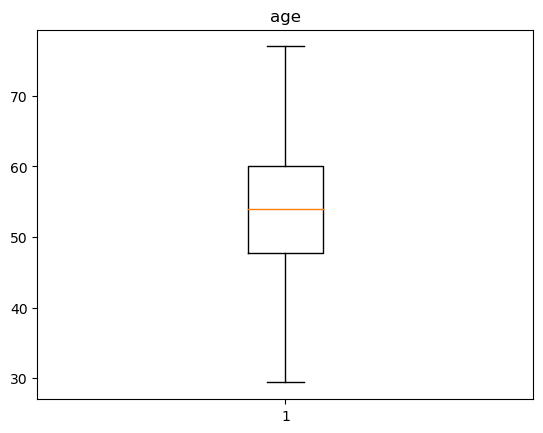

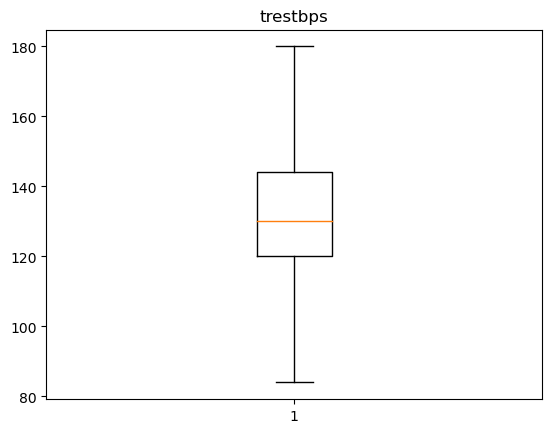

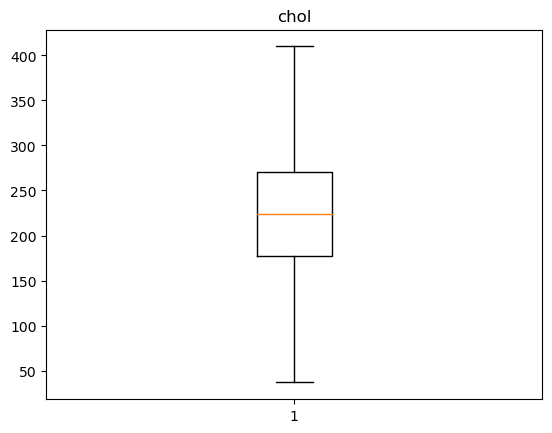

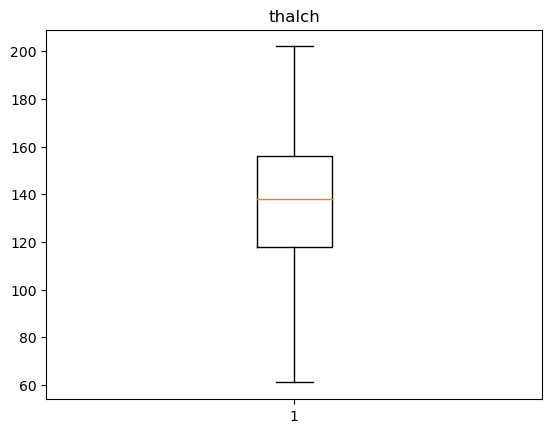

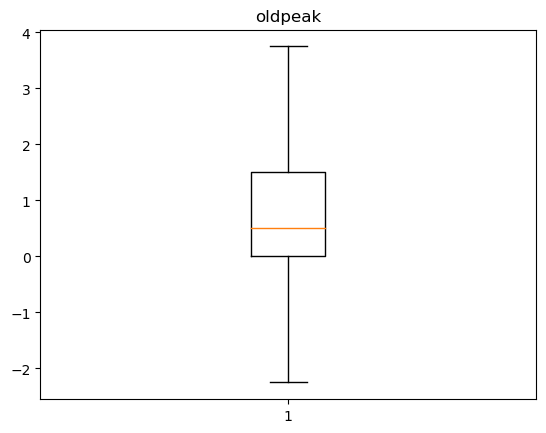

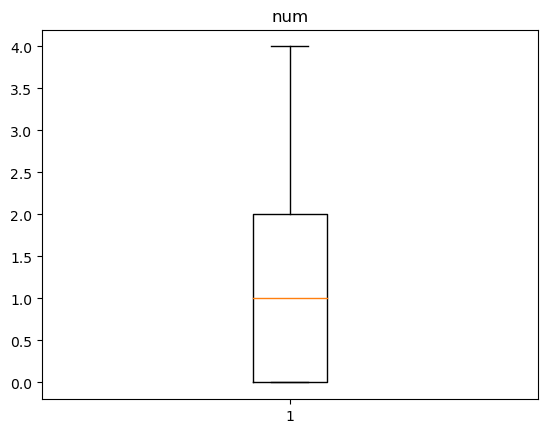

In [22]:
for i in num_cols:
    plt.boxplot(df[i])
    plt.title(i)
    plt.show()

The dataset contains 908 observations with mixed numerical and categorical features. Missing values were identified in the ‘oldpeak’ feature and handled using median imputation to maintain data integrity. Outlier detection was performed using the Interquartile Range (IQR) method on numerical features.

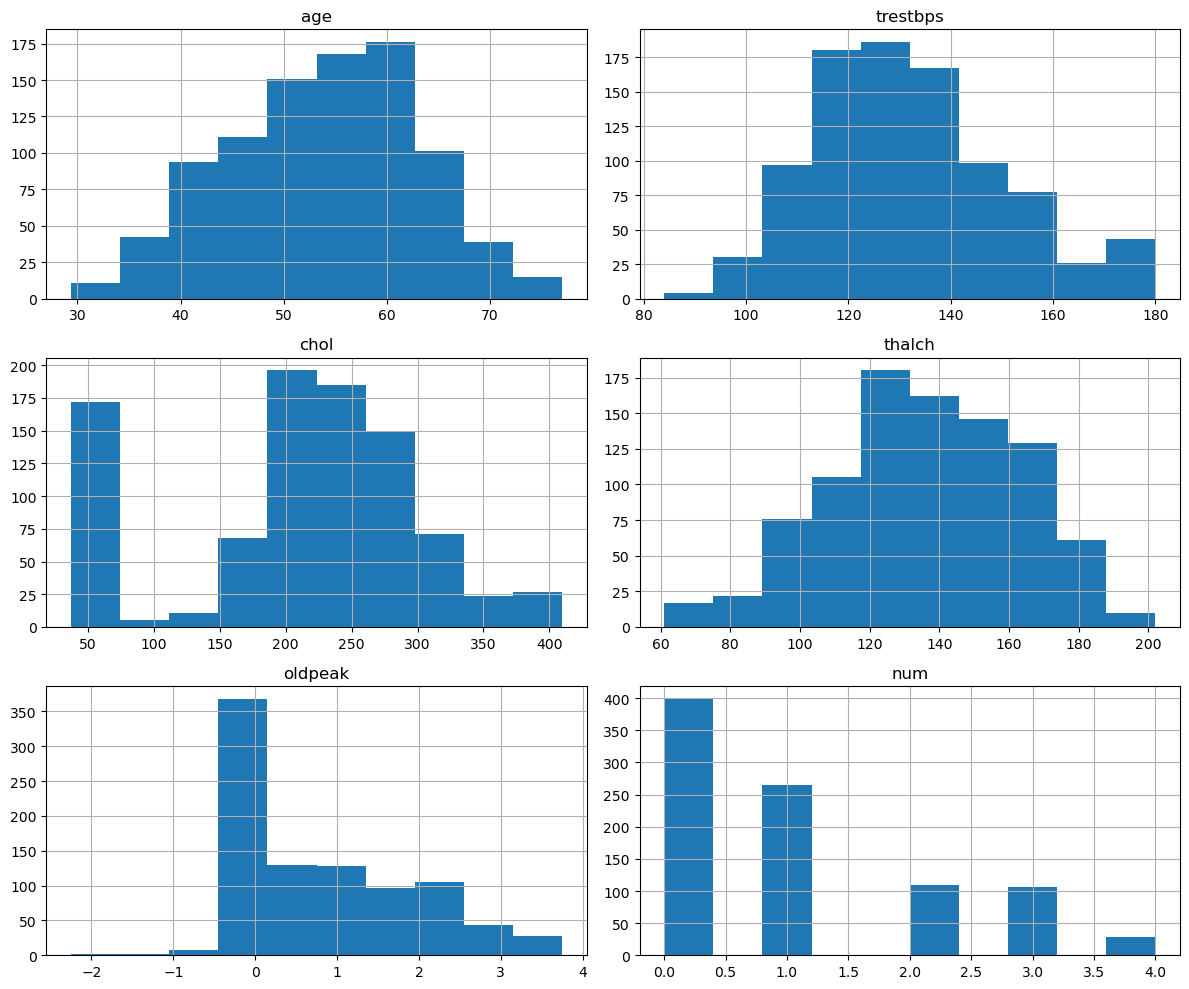

In [28]:
# Histogram
df.hist(figsize=(12,10),bins=10)
plt.tight_layout()
plt.show()

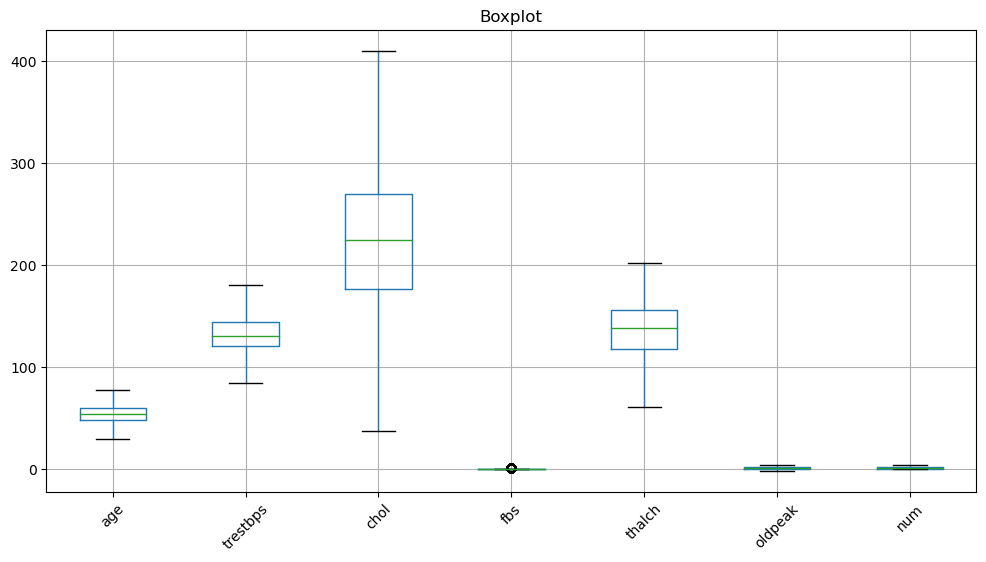

In [29]:
plt.figure(figsize=(12,6))
df.boxplot()
plt.title('Boxplot')
plt.xticks(rotation=45)
plt.show()

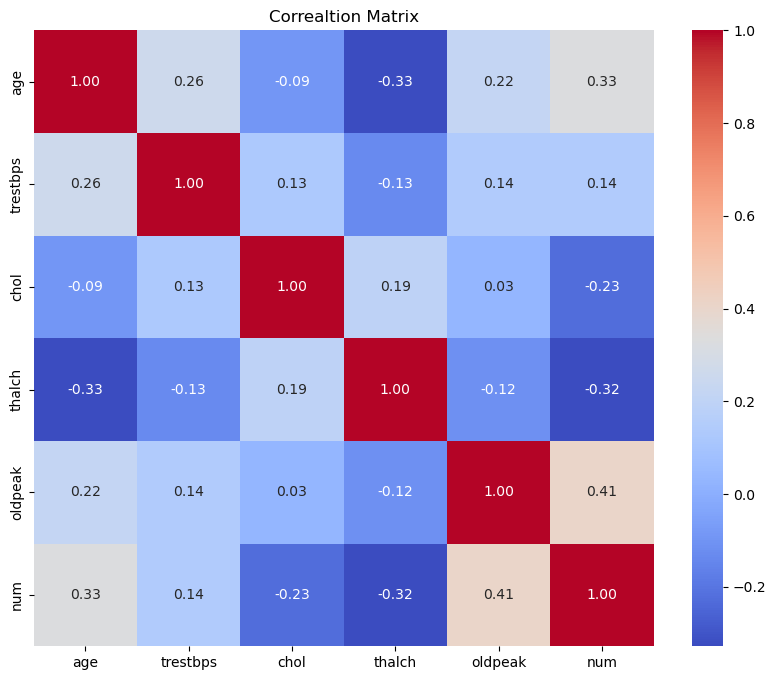

In [31]:
# Correlation Matrix for numerical Cols

corr =df[num_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correaltion Matrix')
plt.show()

Histograms indicate that numerical features such as cholesterol, resting blood pressure, and maximum heart rate show varying distributions, with some mild skewness. Box plots reveal the presence of outliers, which were handled using the IQR method. The correlation heatmap shows moderate relationships between some predictors and the target variable (num), while no extreme multicollinearity is observed among independent features.

## 3. Feature Engineering:

**If necessary, perform feature engineering techniques such as encoding categorical variables, scaling numerical features**


In [33]:
# Categorical Columns in dataset

cat_cols = df.select_dtypes(include=['object']).columns

cat_cols

Index(['sex', 'cp', 'restecg', 'exang', 'slope', 'thal'], dtype='object')

In [34]:
df_encoded = pd.get_dummies(df, columns=cat_cols, drop_first=True)

In [35]:
df_encoded.head()

,age,trestbps,chol,fbs,thalch,oldpeak,num,sex_Male,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,exang_True,exang_FALSE,exang_TURE,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,63.0,145,233.0,True,150,2.3,0,True,False,False,True,False,False,False,False,False,False,False,False,False
1,41.0,135,203.0,False,132,0.0,0,True,True,False,False,True,False,False,False,False,True,False,False,False
2,57.0,140,192.0,False,148,0.4,0,True,False,False,False,True,False,False,False,False,True,False,False,False
3,52.0,118,186.0,False,190,0.0,0,True,False,False,True,False,False,False,False,False,True,False,False,False
4,57.0,110,201.0,False,126,1.5,0,True,False,False,False,True,False,True,False,False,True,False,False,False


In [37]:
df_encoded['fbs'] = df_encoded['fbs'].astype(int)

In [38]:
df_encoded

,age,trestbps,chol,fbs,thalch,oldpeak,num,sex_Male,cp_atypical angina,cp_non-anginal,cp_typical angina,restecg_normal,restecg_st-t abnormality,exang_True,exang_FALSE,exang_TURE,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,63.0,145,233.000,1,150,2.3,0,True,False,False,True,False,False,False,False,False,False,False,False,False
1,41.0,135,203.000,0,132,0.0,0,True,True,False,False,True,False,False,False,False,True,False,False,False
2,57.0,140,192.000,0,148,0.4,0,True,False,False,False,True,False,False,False,False,True,False,False,False
3,52.0,118,186.000,0,190,0.0,0,True,False,False,True,False,False,False,False,False,True,False,False,False
4,57.0,110,201.000,0,126,1.5,0,True,False,False,False,True,False,True,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
903,53.0,125,36.875,0,120,1.5,4,True,False,False,False,True,False,False,False,False,False,True,True,False
904,62.0,166,170.000,0,120,3.0,4,True,False,False,False,False,True,True,False,False,True,False,False,True
905,56.0,170,36.875,0,123,2.5,4,True,False,True,False,False,False,True,False,False,False,False,False,True
906,56.0,144,208.000,1,105,0.5,4,True,False,True,False,False,True,False,False,True,False,False,False,True


Categorical variables such as sex, chest pain type, resting ECG results, exercise-induced angina, slope, and thalassemia were encoded using One-Hot Encoding to convert them into numerical format suitable for Decision Tree modeling. The boolean feature (fbs) was converted into integer format. Feature scaling was not applied because Decision Tree algorithms are not sensitive to feature magnitude and do not rely on distance-based calculations.

## 4. Decision Tree Classification:

**Split the dataset into training and testing sets (e.g., using an 80-20 split).**

**Implement a Decision Tree Classification model using a library like scikit-learn.**

**Train the model on the training set and evaluate its performance on the testing set using appropriate evaluation metrics (e.g., accuracy, precision, recall, F1-score, ROC-AUC).**


In [39]:
X = df_encoded.drop('num',axis=1)
y = df_encoded['num']

In [40]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [41]:
X_train.shape, X_test.shape

((635, 19), (273, 19))

In [42]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [43]:
y_pred = dt_model.predict(X_test)
y_prob = dt_model.predict_proba(X_test)[:,1]

In [48]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test,y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test,y_pred, average='weighted')

print("Accuracy:", round(accuracy,3))
print("Precision:", round(precision,3))
print("Recall:", round(recall,3))
print("F1 Score:", round(f1,3))


Accuracy: 0.48
Precision: 0.478
Recall: 0.48
F1 Score: 0.477


In [49]:
roc_auc = roc_auc_score(y_test, dt_model.predict_proba(X_test), multi_class='ovr')
print("ROC-AUC:", round(roc_auc,3))

ROC-AUC: 0.594


The Decision Tree classifier achieved an accuracy of 48%, indicating relatively low overall predictive performance on the testing dataset. The precision (0.478) and recall (0.480) values suggest that the model struggles to consistently distinguish between different classes of heart disease severity. The F1-score (0.477) further reflects an imbalance between correctly identifying positive cases and avoiding misclassification. The ROC-AUC score of 0.594 indicates that the model performs only slightly better than random classification.

## 5. Hyperparameter Tuning:

**Perform hyperparameter tuning to optimize the Decision Tree model. Experiment with different hyperparameters such as maximum depth, minimum samples split, and criterion.**


In [53]:
param_grid = {
    'max_depth': [None,3,5,10,15],
    'min_samples_split': [2,5,10,20],
    'min_samples_leaf': [1,2,5,10],
    'criterion':['gini', 'entropy']
}

In [54]:
from sklearn.model_selection import GridSearchCV

dt = DecisionTreeClassifier(random_state=42)

grid_search = GridSearchCV(estimator=dt, param_grid=param_grid,cv=5,scoring='accuracy',n_jobs=-1)

%time grid_search.fit(X_train, y_train)

CPU times: total: 1.19 s
Wall time: 9.14 s


GridSearchCV(cv=5, estimator=DecisionTreeClassifier(random_state=42), n_jobs=-1,
             param_grid={'criterion': ['gini', 'entropy'],
                         'max_depth': [None, 3, 5, 10, 15],
                         'min_samples_leaf': [1, 2, 5, 10],
                         'min_samples_split': [2, 5, 10, 20]},
             scoring='accuracy')

In [55]:
print('Best Parameters: ',grid_search.best_params_)
print('Best Cross-Validation Score: ', grid_search.best_score_)

Best Parameters:  {'criterion': 'entropy', 'max_depth': 5, 'min_samples_leaf': 5, 'min_samples_split': 2}
Best Cross-Validation Score:  0.5669291338582677


Hyperparameter tuning was performed using GridSearchCV to optimize the Decision Tree model by adjusting parameters such as maximum depth, minimum samples split, minimum samples leaf, and splitting criterion.

## 6. Model Evaluation and Analysis:

**Analyse the performance of the Decision Tree model using the evaluation metrics obtained.**

**Visualize the decision tree structure to understand the rules learned by the model and identify important features**


In [56]:
# Best tuned model and evaluation

best_dt = grid_search.best_estimator_

y_pred_tuned = best_dt.predict(X_test)

accuracy = accuracy_score(y_test, y_pred_tuned)
precision = precision_score(y_test, y_pred_tuned, average='weighted')
recall = recall_score(y_test, y_pred_tuned, average='weighted')
f1 = f1_score(y_test, y_pred_tuned, average='weighted')

print("Tuned Accuracy:", round(accuracy,3))
print("Tuned Precision:", round(precision,3))
print("Tuned Recall:", round(recall,3))
print("Tuned F1 Score:", round(f1,3))

roc_auc = roc_auc_score(y_test, best_dt.predict_proba(X_test), multi_class='ovr')
print("Tuned ROC-AUC:", round(roc_auc,3))

Tuned Accuracy: 0.505
Tuned Precision: 0.45
Tuned Recall: 0.505
Tuned F1 Score: 0.475
Tuned ROC-AUC: 0.694


After tuning, the model achieved a test accuracy of 50.5%, showing improvement over the baseline model. The recall (0.505) indicates that the model was able to correctly identify approximately 50% of the actual cases across classes. The precision (0.45) and F1-score (0.475) suggest moderate classification performance with some misclassification still present. Notably, the ROC-AUC score improved to 0.694, indicating better overall class separability compared to the initial model.

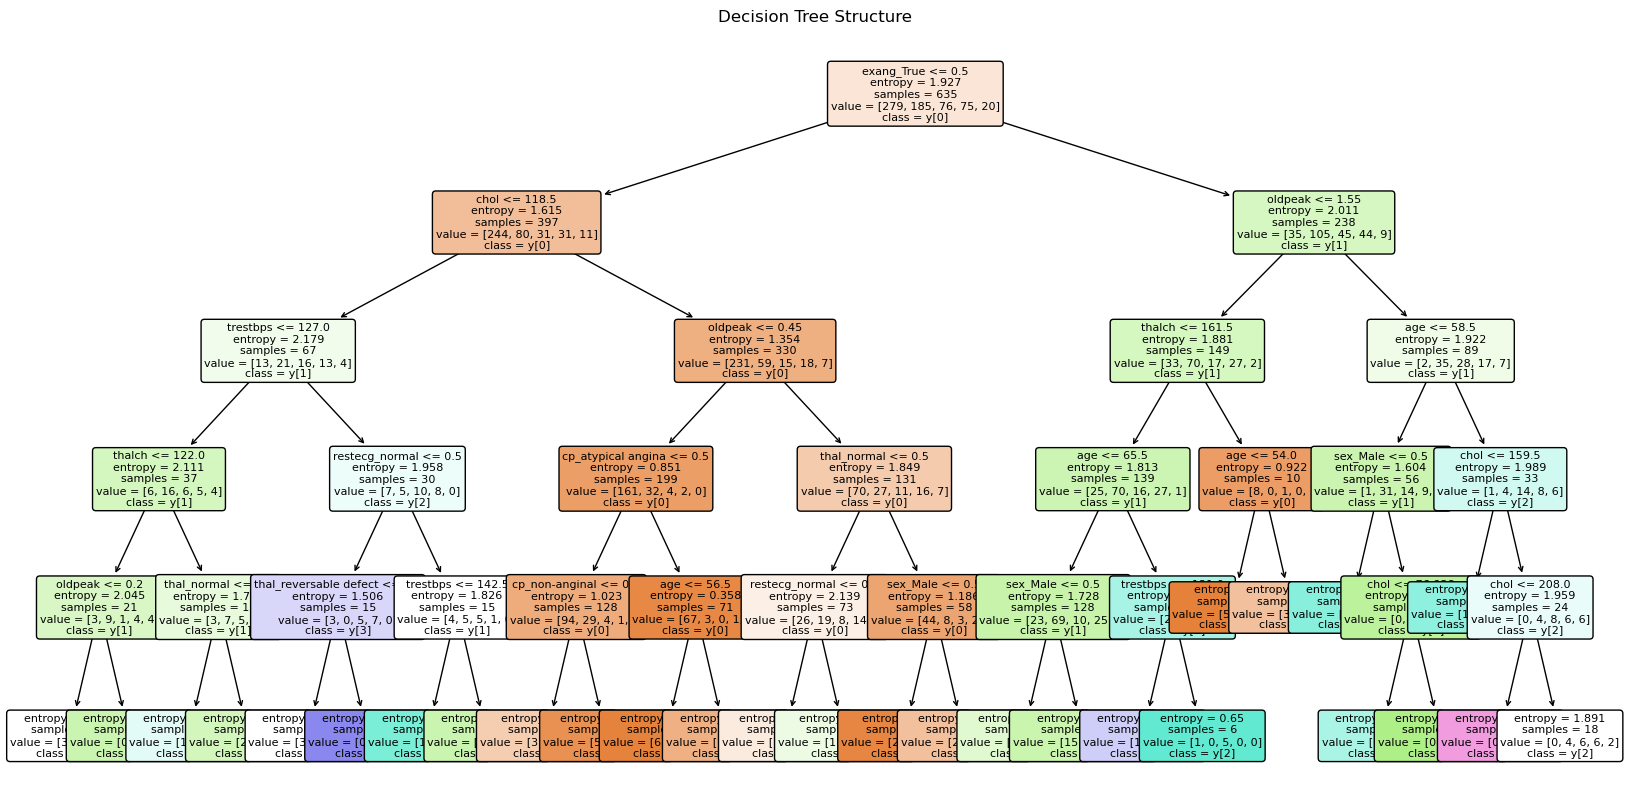

In [57]:
from sklearn.tree import plot_tree

plt.figure(figsize=(20,10))
plot_tree(best_dt, feature_names=X.columns, class_names=True, filled=True, rounded=True,fontsize=8)
plt.title("Decision Tree Structure")
plt.show()

In [58]:
feature_importance = pd.DataFrame({'Feature':X.columns,
                                  'Importance':best_dt.feature_importances_
                                  }).sort_values(by='Importance', ascending=False)

feature_importance.head()

,Feature,Importance
12,exang_True,0.236855
2,chol,0.164944
5,oldpeak,0.159972
0,age,0.083783
6,sex_Male,0.068198


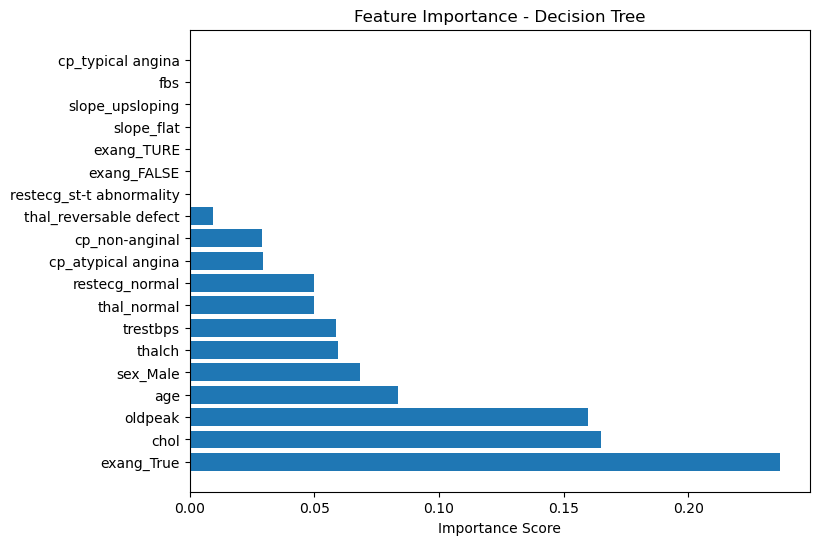

In [59]:
plt.figure(figsize=(8,6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'])
plt.xlabel('Importance Score')
plt.title('Feature Importance - Decision Tree')
plt.show()

The Decision Tree structure was visualized to understand the splitting rules learned by the model. The root node represents the most significant feature influencing heart disease classification. Subsequent splits show how the model partitions the data based on feature thresholds to reduce impurity.

Feature importance analysis reveals that exercise-induced angina (exang_True) is the most influential predictor with an importance score of 0.2369, indicating that the presence of exercise-induced chest pain strongly affects heart disease classification. Cholesterol level (0.1649) and oldpeak (0.1600) are the next most significant features, suggesting that cholesterol levels and ST depression values play a critical role in determining disease severity. Additionally, age (0.0838) and sex_Male (0.0682) contribute moderately to the prediction.

## Interview Questions:

**1. What are some common hyperparameters of decision tree models, and how do they affect the model's performance?**

Some important hyperparameters of Decision Trees include:

**1. max_depth**

Controls the maximum depth of the tree.

Smaller depth → Prevents overfitting.

Larger depth → May overfit training data.

**2. min_samples_split**

Minimum number of samples required to split a node.

Higher value → Makes tree more conservative.

Lower value → More complex tree.

**3. min_samples_leaf**

Minimum samples required at a leaf node.

Prevents creation of very small leaf nodes.

Helps reduce overfitting.

**4. criterion (gini / entropy)**

Measures quality of split.

Gini → Faster computation.

Entropy → Based on information gain.



**2. What is the difference between the Label encoding and One-hot encoding?**

**Label Encoding**

Assigns a unique integer to each category.

Example: Male → 0, Female → 1.

May introduce unintended ordinal relationship.


**One-Hot Encoding**

Creates separate binary columns for each category.

Example: Male → [1,0], Female → [0,1].

Does not introduce order.

Increases dimensionality.